# 4.1 实现LLM的架构

In [35]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length  训练和推理需要保持一致
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers 【核心Transformer模块的重复次数】
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}


In [36]:
# Listing 4.1 A placeholder GPT model architecture class
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])      #A
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])                       #B
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):                                       #C
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):                                                     #D
        return x

class DummyLayerNorm(nn.Module):                                              #E
    def __init__(self, normalized_shape, eps=1e-5):                           #F
        super().__init__()

    def forward(self, x):
        return x


#A 为 TransformerBlock 设置占位符
#B 为 LayerNorm 设置占位符
#C 一个简单的占位类，后续将被真正的 TransformerBlock 替换
#D 该模块无实际操作，仅原样返回输入
#E 一个简单的占位类，后续将被真正的 DummyLayerNorm 替换
#F 此处的参数仅用于模拟LayerNorm接口


此代码中的 DummyGPTModel 类使用 PyTorch 内置的神经网络模块（nn.Module）定义了一个简化版的类 GPT 模型。该类包括 token 嵌入、位置嵌入、dropout、多个 Transformer 模块（DummyTransformerBlock）、最终的层归一化（DummyLayerNorm）以及线性输出层（out_head）。模型配置通过 Python 字典传入，稍后将传入我们之前创建的 GPT_CONFIG_124M 字典。

forward方法定义了数据在模型中的流动方式：计算输入索引的 token 嵌入和位置嵌入，应用 dropout，通过 transformer block 处理数据，应用归一化，最后通过线性输出层生成 logits。

上面的代码已经可以正常运行，不过需要先准备输入数据，在本节后面我们会看到运行效果。需要注意的是，目前代码中我们使用了 DummyLayerNorm 和 DummyTransformerBlock 作为 Transformer 模块和层归一化的占位符，实际的实现会在后续部分详细介绍。

接下来，我们将准备输入数据并初始化一个新的 GPT 模型，以展示它的用法。基于第二章实现的分词器，图 4.4 展示了数据在 GPT 模型中流入和流出的整体流程。

In [37]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)  # return 的是每个token的概率


tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [38]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)


Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


# 使用层归一化对激活值进行标准化

本节中，我们将实现层归一化，以提高神经网络训练的稳定性和效率。

归一化的核心思想是将神经网络层的激活（输出）调整为均值为 0，方差为 1（即单位方差）。这种调整可以加速权重的收敛速度，确保训练过程的一致性和稳定性。正如上一节提到的，在 GPT-2 和现代 Transformer 架构中，层归一化通常应用于多头注意力模块的前后以及最终输出层之前。

In [39]:
# Listing 4.2 A layer normalization class
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


In [40]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5)          #A
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

#A 创建2个训练样本，每个样本有5个维度（特征）


tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [41]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)


Mean:
 tensor([[-2.9802e-08],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


# 实现带有GELU激活函数的前馈神经网络

In [42]:
# Listing 4.3 An implementation of the GELU activation function
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


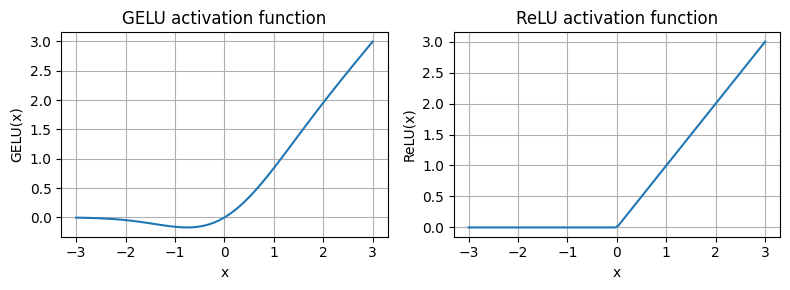

In [43]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)                                          #A
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

#A 在 -3 到 3 的范围内生成 100 个样本数据点


如图所示，GELU 的平滑性使其在训练过程中具有更好的优化特性，能够对模型参数进行更细微的调整。相比之下，ReLU 在零点处有一个拐角，这在网络深度较大或结构复杂时可能会增加优化难度。此外，ReLU 对所有负输入的输出为零，而 GELU 对负值允许一个小的非零输出。这意味着在训练过程中，接收负输入的神经元也能对学习过程产生一定的贡献，尽管贡献程度不及正输入。

In [44]:
# Listing 4.4 A feed forward neural network module
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


# 4.4 残差连接

接下来，我们来讨论快捷连接（也称跳跃连接或残差连接）的概念。快捷连接最初是在计算机视觉中的深度网络（尤其是残差网络）提出的，用于缓解梯度消失问题。梯度消失是指在训练中指导权重更新的梯度在反向传播过程中逐渐减小，导致早期层（靠近输入端的网络层）难以有效训练

In [45]:
# Listing 4.5 A neural network to illustrate shortcut connections
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            # Implement 5 layers
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x


In [46]:
def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])

    # Calculate loss based on how close the target
    # and output are
    loss = nn.MSELoss()
    loss = loss(output, target)

    # Backward pass to calculate the gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")


In [47]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123) # specify random seed for the initial weights for reproducibility
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)


In [48]:
print_gradients(model_without_shortcut, sample_input)

# 从 print_gradients 函数的输出可以看出
# 梯度在从最后一层（layers.4）到第一层（layers.0）时逐渐减小，这种现象称为梯度消失问题。


layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041071094573
layers.3.0.weight has gradient mean of 0.0013988735154271126
layers.4.0.weight has gradient mean of 0.005049645435065031


In [49]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

# 从输出结果可以看到，最后一层（layers.4）的梯度依然比其他层更大。
# 然而，随着接近第一层（layers.0），梯度值逐渐趋于稳定，并未缩小到几乎消失的程度。


layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


总之，快捷连接在解决深度神经网络中的梯度消失问题方面具有重要作用。作为 LLM 的核心构建单元，快捷连接可以确保各层之间的梯度稳定流动，从而帮助 GPT 模型更有效的训练（下一章实现训练过程）。

在介绍了快捷连接后，我们将在下一节把之前讲解的所有概念（层归一化、GELU 激活、前馈网络模块和快捷连接）整合进一个 Transformer 模块中，这是构建 GPT 架构所需的最后一个模块。

# 连接注意力层与线性层

In [50]:
# Listing 3.5 An efficient multi-head attention class
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out,
                context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads                        #A
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)                   #B
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )


    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)                                      #C
        queries = self.W_query(x)                                 #C
        values = self.W_value(x)                                  #C

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)       #D
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)   #D
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim) #D

        keys = keys.transpose(1, 2)                               #E
        queries = queries.transpose(1, 2)                         #E
        values = values.transpose(1, 2)                           #E

        attn_scores = queries @ keys.transpose(2, 3)              #F
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]    #G

        attn_scores.masked_fill_(mask_bool, -torch.inf)           #H

        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2)     #I

        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)  #J
        context_vec = self.out_proj(context_vec)                  #K
        return context_vec


#A 将投影维度缩小，以匹配期望的输出维度
#B 使用线性层组合头部输出
#C 张量形状：(b, num_tokens, d_out)
#D 我们通过添加 num_heads 维度来隐式地拆分矩阵。然后展开最后一个维度，使其形状从 (b, num_tokens, d_out) 转换为 (b, num_tokens, num_heads, head_dim)
#E 将张量的形状从 (b, num_tokens, num_heads, head_dim) 转置为 (b, num_heads, num_tokens, head_dim)
#F 对每个注意力头进行点积运算
#G 掩码被截断到 token 的数量
#H 使用掩码填充注意力分数
#I 张量形状：（b, num_tokens, n_heads, head_dim）
#J 将多个注意力头的输出结果合并，其中输出维度 self.d_out 等于注意力头数 self.num_heads 与每个头的维度 self.head_dim 的乘积
#K 添加一个可选的线性投影层


In [51]:
# Listing 4.6 The transformer block component of GPT

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
        d_in=cfg["emb_dim"],
        d_out=cfg["emb_dim"],
        context_length=cfg["context_length"],
        num_heads=cfg["n_heads"],
        dropout=cfg["drop_rate"],
        qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x                                          #A
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back
        shortcut = x                                          #B
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut                                       #C
        return x


#A 注意力模块中的快捷连接
#B 前馈网络模块中的快捷链接
#C 将原始输入加回到输出中


# 4.6 实现GPT模型

![alt text](../../data/预训练/img/cee9d0c24205e5a09a7b3cdf637adf87.png)

In [52]:
# Listing 4.7 The GPT model architecture implementation
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)

        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))      #A
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

#A 设备设置将根据输入数据所在的位置选择在 CPU 或 GPU 上训练模型

接下来，init 方法会根据 cfg 中指定的层数创建一个由 TransformerBlock 模块组成的顺序堆栈。紧接在 TransformerBlock 堆栈之后应用一个 LayerNorm 层，对其输出进行标准化，从而稳定训练过程。最后，定义了一个无偏置的线性输出层，将 Transformer 的输出投射到分词器的词汇空间，为词汇表中的每个 token 生成对应的 logits。

forward 方法则负责接收一批 token 索引作为输入，计算它们的词嵌入向量，并应用位置嵌入，接着将序列通过 Transformer 模块进行处理，对最终的输出进行归一化，最后计算 logits 来表示下一个 token 的非归一化概率。我们将在下一节将这些 logits 转换为 token 和文本输出。

现在让我们使用 GPT_CONFIG_124M 字典配置来初始化一个具有 1.24 亿参数的 GPT 模型，并将本章开头创建的批量文本作为模型输入。

# 4.7 生成文本

![alt text](../../data/预训练/img/0fb27ae8f4387fc94ad929529c73c93a.png)

In [53]:
# Listing 4.8 A function for the GPT model to generate text
def generate_text_simple(model, idx, max_new_tokens, context_size): #A
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]                           #B
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]                                   #C
        probas = torch.softmax(logits, dim=-1)                      #D
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)       #E
        idx = torch.cat((idx, idx_next), dim=1)                     #F

    return idx


#A idx 是当前上下文中索引的数组，形状为 (batch, n_tokens)
#B 若上下文长度超出支持范围，则进行裁剪。例如，若模型仅支持 5 个 token，而上下文长度为 10，仅使用最后 5 个 token 作为上下文
#C 仅关注最后一个时间步，将形状从 (batch, n_token, vocab_size) 转换为 (batch, vocab_size)
#D probas 的形状为 (batch, vocab_size)
#E idx_next 的形状为 (batch, 1)
#F 将采样的索引追加到当前序列中，此时 idx 的形状为 (batch, n_tokens+1)


在上述代码中，generate_text_simple 函数使用 Softmax 函数将 logits 转换为概率分布，然后通过 torch.argmax 找出概率最高的位置。Softmax 函数是单调的，这意味着它会保持输入的相对顺序，因此，Softmax 这一步实际上是冗余的，因为 Softmax 输出中最高值的位置与原始 logits 中最高值的位置相同。换句话说，我们可以直接对 logits 应用 torch.argmax 得到相同的结果。不过，我们保留了这个转换过程，以展示从 logits 到概率的完整过程，有助于理解模型如何生成最可能的下一个词，这种方式称为贪婪解码。

在下一章中，我们将在实现 GPT 训练代码的同时，引入一些新的采样技术，通过修改 softmax 输出，使模型在生成文本时不总是选择概率最高的词，这可以增加文本的多样性和创造性。

![alt text](../../data/预训练/img/e17600632d89a98f00e919cecb5ab481.png)

In [54]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)            #A
print("encoded_tensor.shape:", encoded_tensor.shape)

#A  添加批次维度


encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [55]:
model.eval()             #A
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output:", out)
print("Output length:", len(out[0]))

#A 禁用 dropout，因为当前不是在训练模型


Output: tensor([[15496,    11,   314,   716, 12170, 44251, 25952, 49216, 30322,  6868]])
Output length: 10


In [56]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)


Hello, I am drone Omni SSLmyra muc native


从以上的输出可以看到，模型生成的是一些毫无意义的内容，完全不像图 4.18 中的连贯文本。这是为什么呢？原因在于模型还没有经过训练。到目前为止，我们只是实现了 GPT 架构，并用随机权重初始化了模型实例。

模型训练本身就是一个庞大的主题，我们将在下一章详细讨论。